In [87]:
import os 
from omegaconf import OmegaConf

cfg = OmegaConf.load("cfgs/data.yaml")
file_dir = os.path.expanduser(cfg.file_dir)

files = os.listdir(file_dir)

if cfg.with_depth: 
    depth_files = list(filter(lambda x: "depth" in x, files))
    file_paths = list(map(lambda x: os.path.join(file_dir, x), depth_files))
else: 
    rgb_files = list(filter(lambda x: "depth" not in x, files))
    file_paths = list(map(lambda x: os.path.join(file_dir, x), rgb_files))

file_paths

['/home/bing_TUM/ehrensberger/master-thesis/imports/mimicgen/datasets/robot/square_d1_panda_depth.hdf5',
 '/home/bing_TUM/ehrensberger/master-thesis/imports/mimicgen/datasets/robot/square_d1_iiwa_depth.hdf5',
 '/home/bing_TUM/ehrensberger/master-thesis/imports/mimicgen/datasets/robot/square_d0_ur5e_depth.hdf5',
 '/home/bing_TUM/ehrensberger/master-thesis/imports/mimicgen/datasets/robot/square_d0_panda_depth.hdf5',
 '/home/bing_TUM/ehrensberger/master-thesis/imports/mimicgen/datasets/robot/square_d1_ur5e_depth.hdf5',
 '/home/bing_TUM/ehrensberger/master-thesis/imports/mimicgen/datasets/robot/square_d1_sawyer_depth.hdf5',
 '/home/bing_TUM/ehrensberger/master-thesis/imports/mimicgen/datasets/robot/square_d0_iiwa_depth.hdf5',
 '/home/bing_TUM/ehrensberger/master-thesis/imports/mimicgen/datasets/robot/square_d0_sawyer_depth.hdf5']

In [88]:
import pandas as pd 

data_path = os.path.expanduser(cfg.data_path)
old_df = pd.read_csv(data_path, index_col=0)

old_df

,views,square_d0_iiwa,square_d0_panda,square_d0_sawyer,square_d0_ur5e,square_d1_iiwa,square_d1_panda,square_d1_sawyer,square_d1_ur5e
0,NaN,0.195513,0.215539,0.149393,0.163103,0.194127,0.206162,0.112876,0.118968
1,NaN,2.712843,2.712843,2.712843,2.712843,2.712831,2.712831,2.712831,2.712831
2,NaN,0.016345,0.031269,0.019400,0.016344,0.016458,0.016456,0.016457,0.016458
3,NaN,1.575012,1.492126,1.481927,1.589442,1.694932,2.899835,1.589322,1.777448


In [49]:
cols = list(old_df.columns[1:])

if cfg.with_depth: 
    files_no_data = [file.replace("_depth.hdf5", "") for file in depth_files if file.replace("_depth.hdf5", "") not in cols]
else: 
    files_no_data = [file for file in rgb_files if file not in cols]
 
files_no_data
        

[]

In [50]:
file_paths_no_data = [f for f in file_paths if any(n in f for n in files_no_data)]

file_paths_no_data


[]

In [51]:
import h5py
import numpy as np
from tqdm import tqdm 

depth_limits = {}

file_paths_no_data = tqdm(file_paths_no_data)
for file in file_paths_no_data: 
    file_paths_no_data.set_description(desc=f"Iterating over file: {file}")
    if depth_limits.get(file, None) != None: 
        continue 

    with h5py.File(file, "r") as hf: 
        print(f"Collecting depth values for file {file}")
        
        file_limits = {}
        data = hf["data"]
        
        for i, demo in enumerate(data):
            for member in data[demo]["obs"]: 
                if "depth" in member: # "robot0_eye_in_hand_depth", "agentview_depth"
                    depth_data = data[demo]["obs"][member][()]
                     
                    if (not i) and (file_limits.get(f"{member}_min", None) is None):    
                        file_limits[f"{member}_min"] = [] 
                    if (not i) and (file_limits.get(f"{member}_max", None) is None): 
                        file_limits[f"{member}_max"] = []  
                    
                    file_limits[f"{member}_min"].append(np.min(depth_data)) # min depth value for current demo 
                    file_limits[f"{member}_max"].append(np.max(depth_data)) # max depth value for current demo 
                    
        print(f"Adding depth values to global dictionary for file {file}")
        file = file.split("/")[-1].replace("_depth.hdf5", "")
        
        depth_limits[file] = {}
        for key in file_limits: 
            if "min" in key: 
                depth_limits[file][key] = np.min(file_limits[key])
            elif "max" in key: 
                depth_limits[file][key] = np.max(file_limits[key])    
                
depth_limits  

0it [00:00, ?it/s]


{}

In [89]:
new_df = pd.DataFrame(depth_limits).sort_index(axis=1)

new_df

""


In [107]:
if not new_df.empty: 
    df = pd.concat([old_df, new_df], axis=1)
    df = df.loc[:, ~df.columns.duplicated()]
    df = df.sort_index(axis=1)

    df = df.rename_axis("views").reset_index()
else: 
    df = old_df
df

,views,square_d0_iiwa,square_d0_panda,square_d0_sawyer,square_d0_ur5e,square_d1_iiwa,square_d1_panda,square_d1_sawyer,square_d1_ur5e
0,agentview_depth,0.195513,0.215539,0.149393,0.163103,0.194127,0.206162,0.112876,0.118968
1,agentview_depth,2.712843,2.712843,2.712843,2.712843,2.712831,2.712831,2.712831,2.712831
2,robot0_eye_in_hand,0.016345,0.031269,0.019400,0.016344,0.016458,0.016456,0.016457,0.016458
3,robot0_eye_in_hand,1.575012,1.492126,1.481927,1.589442,1.694932,2.899835,1.589322,1.777448


In [108]:
depths = df.to_csv("data/files/depths.csv")

In [109]:
views_col = ["agentview_depth"]*2 + ["robot0_eye_in_hand"]*2
df["views"] = views_col

long_df = df.melt(id_vars=["views"], var_name="recoding",value_name="depth")

long_df

,views,recoding,depth
0,agentview_depth,square_d0_iiwa,0.195513
1,agentview_depth,square_d0_iiwa,2.712843
2,robot0_eye_in_hand,square_d0_iiwa,0.016345
3,robot0_eye_in_hand,square_d0_iiwa,1.575012
4,agentview_depth,square_d0_panda,0.215539
5,agentview_depth,square_d0_panda,2.712843
6,robot0_eye_in_hand,square_d0_panda,0.031269
7,robot0_eye_in_hand,square_d0_panda,1.492126
8,agentview_depth,square_d0_sawyer,0.149393
9,agentview_depth,square_d0_sawyer,2.712843


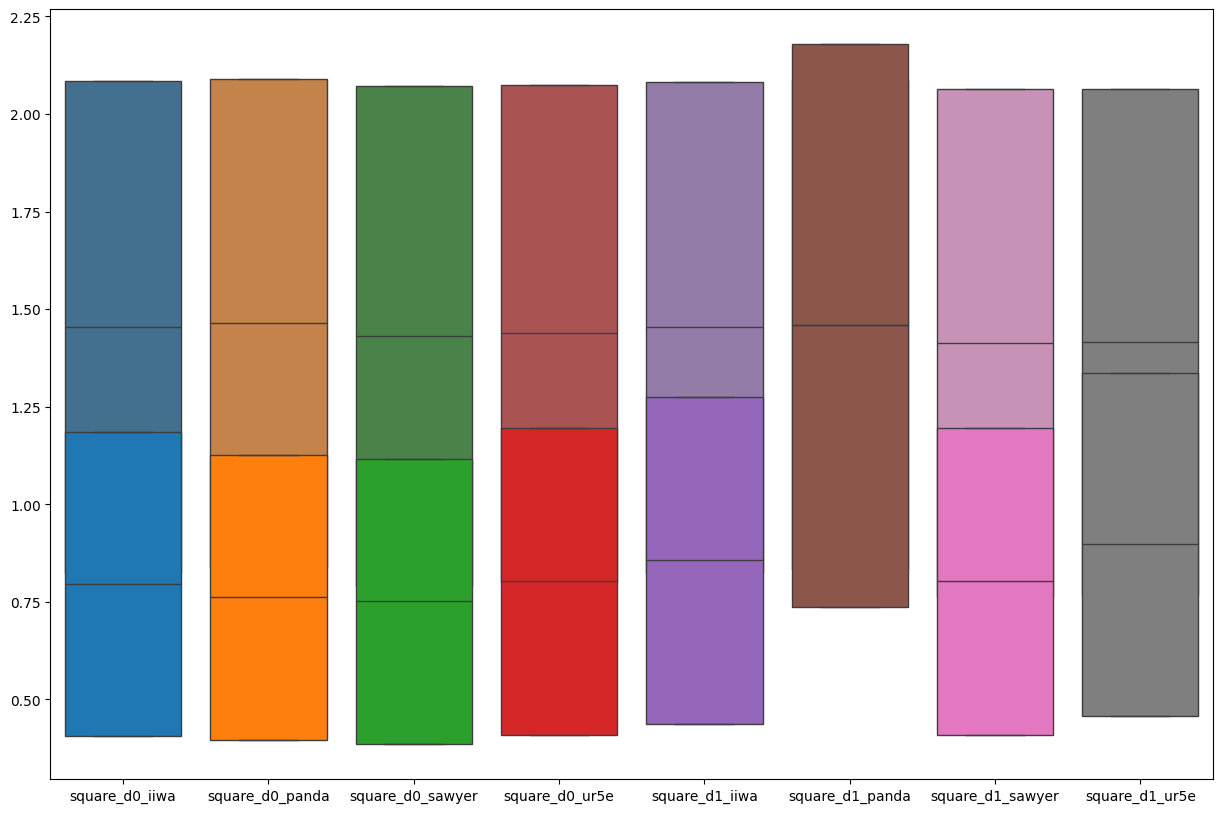

In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 10))

bar_agent = sns.boxplot(data=df.iloc[:2, :], saturation=0.5, fill=True, whis=0, showfliers=False, hue="views")
bar_eye_in_hand = sns.boxplot(data=df.iloc[2:, :], saturation=1, fill=True, whis=0, showfliers=False, hue="views")
plt.show()